<center><h1>Loke_Eliza_HW2</h1></center>
<br>
<br>

Name: Eliza Loke
<br>
Github Username: eliza-data
<br>
USC ID: 9840375742

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
from pathlib import Path
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


Get the Cycle Power Plant Data Set

In [2]:
#1(a).
# Directory setup for data files 
NOTEBOOK_DIR = Path('.').resolve()
DATA_DIR = NOTEBOOK_DIR / 'CCPP'

### (b) Exploring the data

#### i. rows and columns

In [3]:
#1(b)
# Load dataframe from Sheet1
df = pd.read_excel(DATA_DIR / 'Folds5x2_pp.xlsx', sheet_name='Sheet1')
#print(df.head())

# Check for nuber of rows and columns
rows, columns = df.shape
print(f'The dataset has {rows} rows and {columns} columns.')

# Read Readme.txt
readme_path = DATA_DIR / 'Readme.txt'
with open(readme_path, 'r') as f:
  readme_text = f.read()

# Find the end position of the phrase "of the plant." in the Readme.txt
target_phrase = ' of the plant.'
end_pos = readme_text.find(target_phrase) + len(target_phrase)

print('\n- Readme Contents -')
print(readme_text[:end_pos])

# Explicit representation explanation
print('\n' + '=' * 60)
print('1(b)i:')
print(
    f'Rows ({rows}): Each row represents an hourly average record of operational'
    ' and environmental data collected from a Combined Cycle Power Plant'
    ' operating under full load over 6 years (2006–2011).'
)
print(f'Columns ({columns}):')
print('   - AT: Ambient Temperature in °C (Predictor)')
print('   - V: Exhaust Vacuum in cm Hg (Predictor)')
print('   - AP: Ambient Pressure in millibar (Predictor)')
print('   - RH: Relative Humidity in % (Predictor)')
print(
    '   - PE: Net hourly Electrical Energy Output in MW (Target Variable)'
)
print('=' * 60)


The dataset has 9568 rows and 5 columns.

- Readme Contents -
The dataset contains 9568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.

1(b)i:
Rows (9568): Each row represents an hourly average record of operational and environmental data collected from a Combined Cycle Power Plant operating under full load over 6 years (2006–2011).
Columns (5):
   - AT: Ambient Temperature in °C (Predictor)
   - V: Exhaust Vacuum in cm Hg (Predictor)
   - AP: Ambient Pressure in millibar (Predictor)
   - RH: Relative Humidity in % (Predictor)
   - PE: Net hourly Electrical Energy Output in MW (Target Variable)


#### ii. pairwise scatterplots of all the varianbles

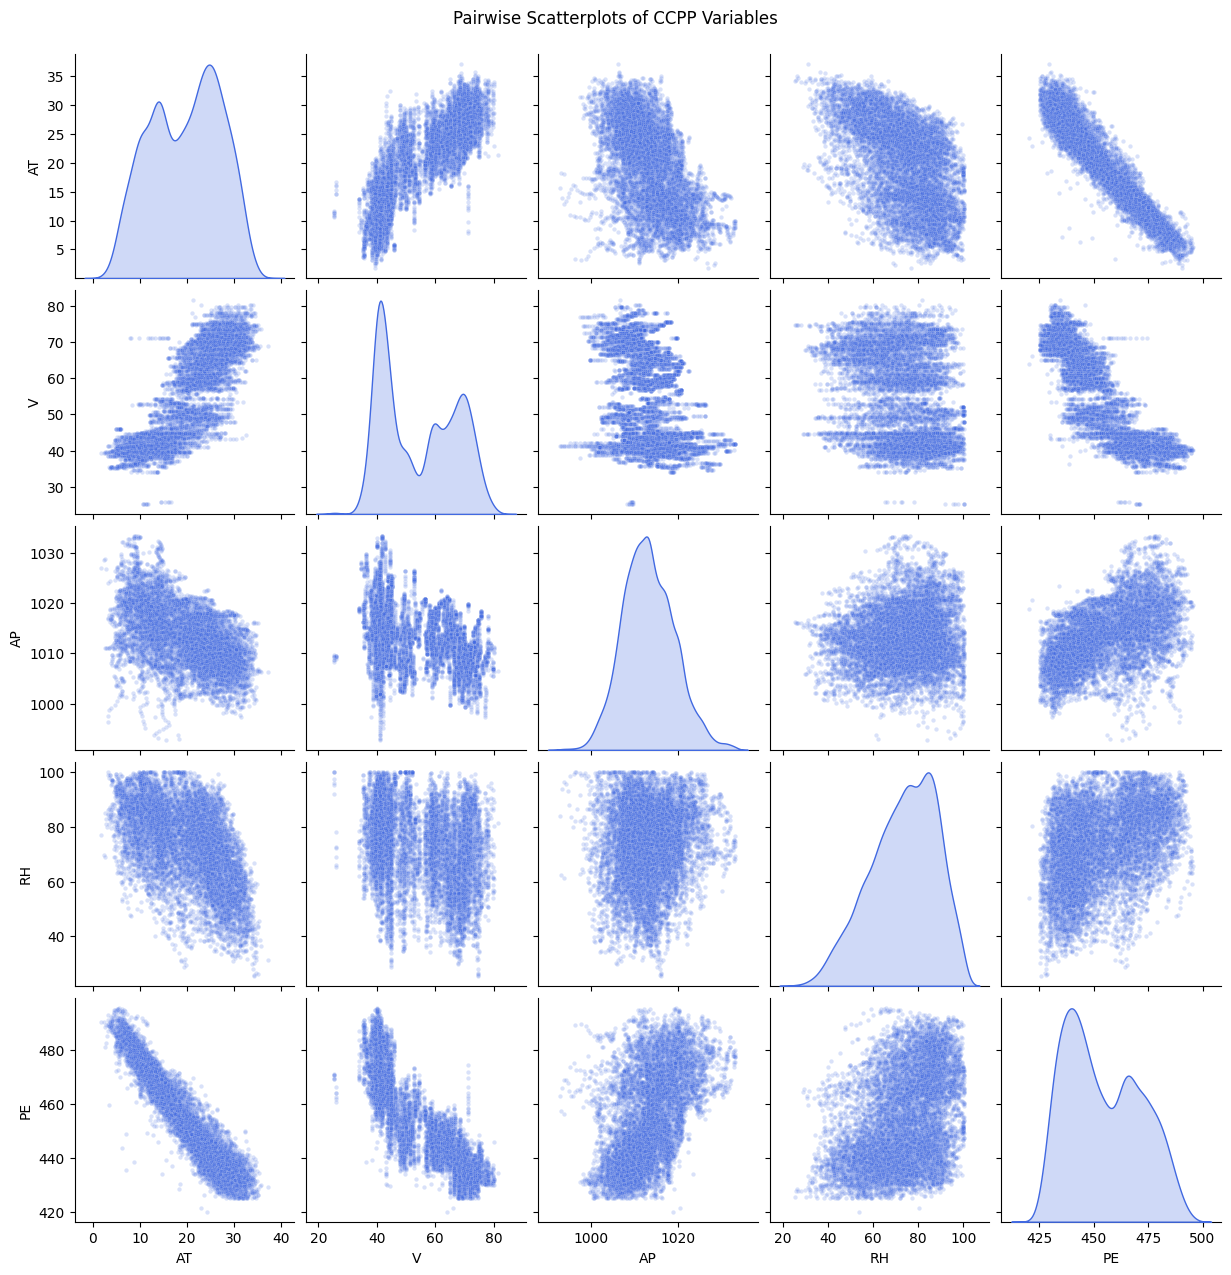

In [4]:
#1(b)ii.
# Create pairwise scatterplot matrix for all variables
pairplot_fig = sns.pairplot(
    df,
    diag_kind='kde',
    plot_kws={'alpha': 0.20, 's': 10, 'color': '#4169E1'},
    diag_kws={'color': '#4169E1', 'fill': True},
)

pairplot_fig.figure.suptitle(
    'Pairwise Scatterplots of CCPP Variables', y=1.02, fontsize=12
)
plt.show()

Pairwise Scatterplot Findings

The following describes the relationship between the predictors ('AT, V, AP, RH') vs. the target variable ('PE'). 
Ambient Temperature ('AT') vs. ('PE'): strong negative linear relationship
Exhaust Vacuum ('V') vs. (PE`): moderate negative linear relationship
Ambient Pressure ('AP') vs. ('PE'): moderate positive correlation
Relative Humidity ('RH') vs. ('PE'): weak positive correlation


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
#1(b)iii.
# Calculate mean, median, range, Q1, Q3, and IQR for each variable
summary_stats = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range': df.max() - df.min(),
    'First Quartile (Q1)': df.quantile(0.25),
    'Third Quartile (Q3)': df.quantile(0.75),
    'Interquartile Range (IQR)': df.quantile(0.75) - df.quantile(0.25)
})

# Display the summary table rounded to 2 decimal places
print("=== Section 1(b)iii Summary Statistics ===")
display(summary_stats.round(2))

=== Section 1(b)iii Summary Statistics ===


,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),Interquartile Range (IQR)
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

--- Predictor: AT ---
  Intercept: 497.0341, Slope: -2.1713
  R-squared: 0.8989, p-value: 0.00e+00
  Association: Statistically Significant

  Potential Outliers (|std residual| > 3.5): 20 points

--- Predictor: V ---
  Intercept: 517.8015, Slope: -1.1681
  R-squared: 0.7565, p-value: 0.00e+00
  Association: Statistically Significant

  Potential Outliers (|std residual| > 3.5): 16 points

--- Predictor: AP ---
  Intercept: -1055.2610, Slope: 1.4899
  R-squared: 0.2688, p-value: 0.00e+00
  Association: Statistically Significant

  Potential Outliers (|std residual| > 3.5): 5 points

--- Predictor: RH ---
  Intercept: 420.9618, Slope: 0.4557
  R-squared: 0.1519, p-value: 0.00e+00
  Association: Statistically Significant

  Potential Outliers (|std residual| > 3.5): 0 points



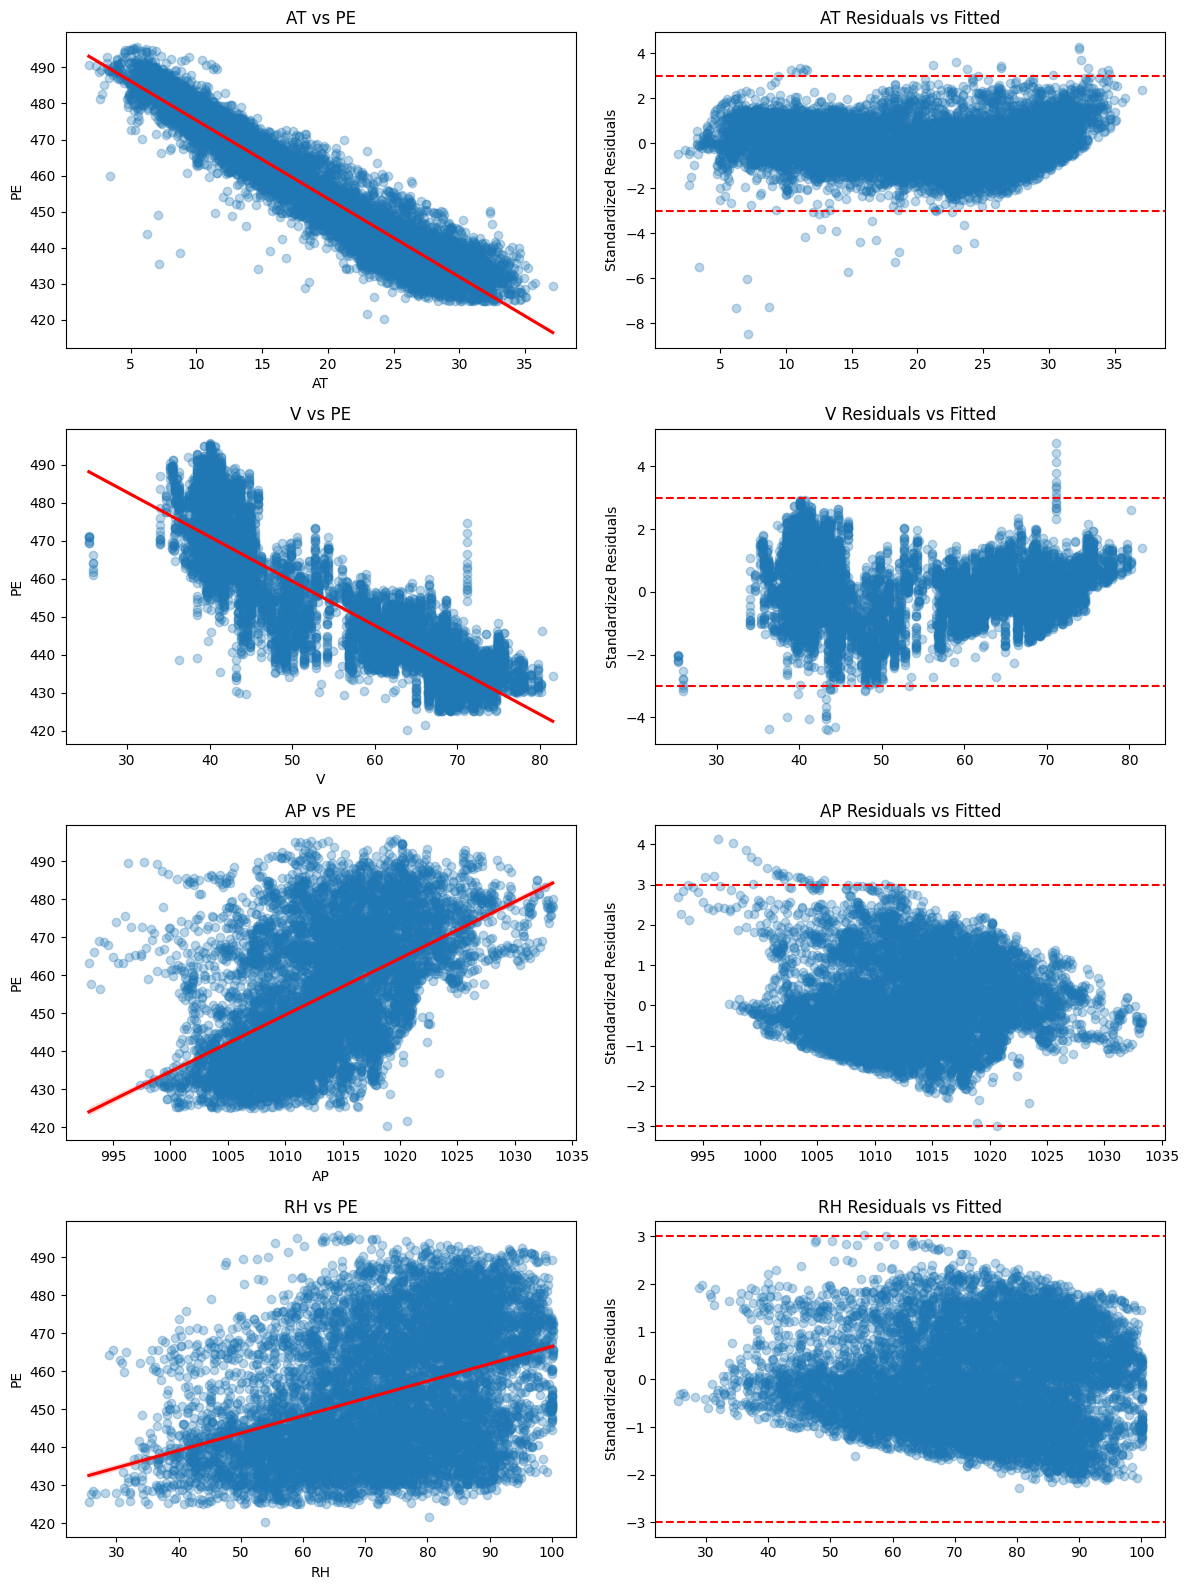

In [6]:
#1c. 
### Plots to visualize the regression lines and residuals for each predictor variable ###

predictors = ['AT', 'V', 'AP', 'RH']
response = 'PE'

# Prepare a plot grid for regression lines & residuals
fig, axes = plt.subplots(len(predictors), 2, figsize=(12, 16))

for i, p in enumerate(predictors):
    # 1. Fit Linear Regression using scipy or statsmodels
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[p], df[response])
    
    print(f"--- Predictor: {p} ---")
    print(f"  Intercept: {intercept:.4f}, Slope: {slope:.4f}")
    print(f"  R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}")
    
    # Check statistical significance
    sig = "Statistically Significant" if p_value < 0.05 else "Not Statistically Significant"
    print(f"  Association: {sig}\n")

    # 2. Scatter plot with regression line
    sns.regplot(x=df[p], y=df[response], ax=axes[i, 0], 
                line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
    axes[i, 0].set_title(f'{p} vs {response}')
    
    # 3. Residual plot to inspect for outliers and non-linearity
    X = sm.add_constant(df[p])
    model = sm.OLS(df[response], X).fit()
    residuals = model.resid
    
    # Standardized residuals for outlier detection (|std_res| > 3 indicates potential outlier)
    std_residuals = model.get_influence().resid_studentized_internal
    outliers = df[np.abs(std_residuals) > 3.5]
    print(f"  Potential Outliers (|std residual| > 3.5): {len(outliers)} points\n")

    axes[i, 1].scatter(df[p], std_residuals, alpha=0.3)
    axes[i, 1].axhline(y=3, color='r', linestyle='--')
    axes[i, 1].axhline(y=-3, color='r', linestyle='--')
    axes[i, 1].set_title(f'{p} Residuals vs Fitted')
    axes[i, 1].set_ylabel('Standardized Residuals')

plt.tight_layout()
plt.show()

Simple Linear Regression Analysis 
Statistical Significance: All four predictors (AT, V, AP, RH) have a statistically significant association with power output (PE) (p<0.0001)
 
Outlier Analysis 
Outliers Identified: A studentized residual threshold of|r_i| > 3.5, extreme outliers were (AT: 20, V: 16, AP: 5, RH: 0).
Removal Decision:These points should not be removed. Keeping them ensures the model remains representative of peak power plant operations.

### (d) Multiple Regression

In [7]:
#1(d).
# Define independent variables (predictors) and dependent variable (response)
X = df[['AT', 'V', 'AP', 'RH']]
X = sm.add_constant(X)  # Adds the intercept (beta_0) term
y = df['PE']

# Fit Multiple Linear Regression model
multiple_model = sm.OLS(y, X).fit()

# Display complete summary table
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:39:25   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

Multiple Regression Model Results

Null Hypothesis Decision : reject the null hypothesis for all four predictors since values extremely close to zero (p<0.0001). 
This confirming all four environmental features have a statistically significant relationship with power output ('PE').

Overall Model Performance: 
R-squared value: 0.929 of the variance** in power output

Four Predictor Coefficients: 
AT: −1.98 (strongest negative driver)
V: −0.23 (negative)
AP: +0.06 (positive)
RH: −0.16 (negative)

### (e) 1c Compare to 1d

In [8]:
#1.e.
# Extract Univariate Coefficients (1c) 
simple_coefs = {
    p: sm.OLS(df[response], sm.add_constant(df[p])).fit().params[p] 
    for p in predictors
}

# 2. Extract Multiple Regression Coefficients (1d)
multi_model = sm.OLS(df[response], sm.add_constant(df[predictors])).fit()
multi_coefs = multi_model.params.drop('const').to_dict()

# 3. Combine into a DataFrame for plotting or inspection
df_coefs = pd.DataFrame({
    'Univariate': simple_coefs,
    'Multiple': multi_coefs
})

print(df_coefs)

    Univariate  Multiple
AT   -2.171320 -1.977513
V    -1.168135 -0.233916
AP    1.489872  0.062083
RH    0.455650 -0.158054


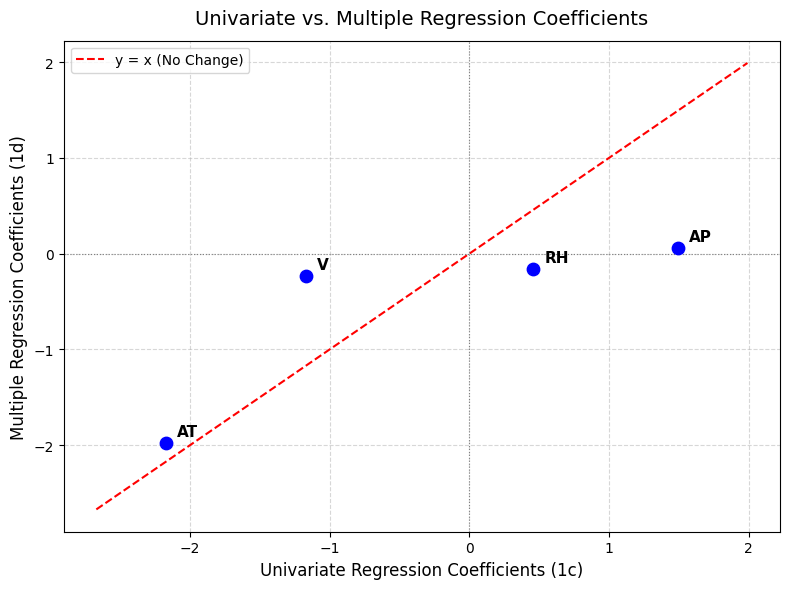

In [9]:
#1.e.
### Plot univariate regression coeﬃcients from 1c on the x-axis, and the multiple regression coeﬃcients from 1d on the y-axis. ###

plt.figure(figsize=(8, 6))

# Plot points directly from df_coefs
plt.scatter(df_coefs['Univariate'], df_coefs['Multiple'], color='blue', s=80, zorder=5)

# Annotate each point with its feature name
for feature in df_coefs.index:
    plt.annotate(
        feature, 
        (df_coefs.loc[feature, 'Univariate'], df_coefs.loc[feature, 'Multiple']),
        textcoords="offset points", 
        xytext=(8, 5), 
        ha='left', 
        fontsize=11, 
        weight='bold'
    )

# Add reference line y = x (where univariate equals multiple coefficient)
min_val = min(df_coefs.min()) - 0.5
max_val = max(df_coefs.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (No Change)')

# Reference axis lines at zero
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(0, color='gray', linewidth=0.8, linestyle=':')

plt.title('Univariate vs. Multiple Regression Coefficients', fontsize=14, pad=12)
plt.xlabel('Univariate Regression Coefficients (1c)', fontsize=12)
plt.ylabel('Multiple Regression Coefficients (1d)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Comparison of Univariate (1c) vs. Multiple Regression (1d) 

Univariate (1c): Measures the isolated marginal effect of a single predictor, ignoring all other environmental conditions.
Multiple (1d):Measures the partial effects of each predictor while holding all other variables constant.

(AT):
AT stays consistent since it is the primary driver of electrical output.

(V & AP):
Coefficients for V and AP are significantly towards zero since their strong univariate correlations with power output due to correlation with AT.

(RH):
RH flips from positive ($+0.46$) to negative ($-0.16$). In univariate regression, higher humidity coincides with lower temperatures (which boosts output). Once temperature and vacuum are controlled for, humidity shows its true net negative effect on plant output.

### (f) Nonlinear Association

In [10]:
#1.f.
### Fit polynomial model (Y = b0 + b1*X + b2*X^2 + b3*X^3) for each predictor ###

poly_models = {}

# Fit polynomial model (Y = b0 + b1*X + b2*X^2 + b3*X^3) for each predictor
for p in predictors:
    formula = f"PE ~ {p} + I({p}**2) + I({p}**3)"
    model = smf.ols(formula, data=df).fit()
    poly_models[p] = model
    
    print(f"==================== Polynomial Model for {p} ====================")
    print(model.summary())
    print("\n")

==================== Polynomial Model for AT ====================
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:39:25   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

/var/folders/2x/gpfp9qcs31nb9dmgq5m75f5m0000gn/T/ipykernel_8895/2219248629.py:9: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols(formula, data=df).fit()


1(f). Polynomial Model Analysis - Evidence of Non-linear Associations

Evidence of nonlinear association between the predictors and the response: 
All four predictors demonstrate nonlinear association with target variable, since both the squared and cubed terms have p-values equal to zero (p < 0.)

Statistical Significance (p < 0.05)
AT, AP, and RH: Both the quadratic and cubic terms are significant (p < 0.0001).
V:The quadratic term is not significant (p = 0.291), but the cubic term (V^3) is significant (p = 0.003). 

We reject beta_2 = beta_3 for all four variables, due to non-linear relationships.

### (g) Interactions of Predictors

In [11]:
# 1(g).
# Fit full linear regression model with all pairwise interaction terms
# The syntax '(AT + V + AP + RH)**2' automatically includes all 4 main effects + 6 pairwise interactions
interaction_terms = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()

# Print the regression summary
print(interaction_terms.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:39:25   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

1(g). Interactions of Predictors Interpretations

Results demonstrate all pairwise interaction terms are statistically significant. 
All six interaction terms yield p-values below 0.05. 
Interactions terms:
AT:AP, AT:RH, V:AP, V:RH, AP:RH are  significant with p<0.0001
while AT:V is significant at p=0.0194.

### (h) Improvement

In [12]:
#1(h).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# MODEL 1: Baseline (Main Effects)
m1 = LinearRegression().fit(X_train, y_train)

m1_train_mse = mean_squared_error(y_train, m1.predict(X_train))
m1_test_mse = mean_squared_error(y_test, m1.predict(X_test))

# MODEL 2: All Degree-2 Terms (Interactions + Quadratics)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

m2 = LinearRegression().fit(X_train_poly, y_train)

m2_train_mse = mean_squared_error(y_train, m2.predict(X_train_poly))
m2_test_mse = mean_squared_error(y_test, m2.predict(X_test_poly))

# Print Results
print(f"Model 1 - Train MSE: {m1_train_mse:.4f} | Test MSE: {m1_test_mse:.4f}")
print(f"Model 2 - Train MSE: {m2_train_mse:.4f} | Test MSE: {m2_test_mse:.4f}")

Model 1 - Train MSE: 20.5808 | Test MSE: 21.2399
Model 2 - Train MSE: 17.8883 | Test MSE: 18.6503


### (i) KNN

In [13]:
#1(i).

#### KNN Regression with and without Feature Scaling ###
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Pre-allocate arrays for metrics
k_range = np.arange(1, 101)
raw_tr_mse, raw_te_mse = np.zeros(100), np.zeros(100)
scl_tr_mse, scl_te_mse = np.zeros(100), np.zeros(100)

# Train and Evaluate
for idx, k in enumerate(k_range):
    # Raw KNN
    knn_raw = KNeighborsRegressor(n_neighbors=k).fit(X_tr, y_tr)
    raw_tr_mse[idx] = mean_squared_error(y_tr, knn_raw.predict(X_tr))
    raw_te_mse[idx] = mean_squared_error(y_te, knn_raw.predict(X_te))
    
    # Scaled KNN
    knn_scl = KNeighborsRegressor(n_neighbors=k).fit(X_tr_s, y_tr)
    scl_tr_mse[idx] = mean_squared_error(y_tr, knn_scl.predict(X_tr_s))
    scl_te_mse[idx] = mean_squared_error(y_te, knn_scl.predict(X_te_s))

# Best k values
best_k_raw = k_range[np.argmin(raw_te_mse)]
best_k_scl = k_range[np.argmin(scl_te_mse)]

print(f"Optimal k (Raw): k = {best_k_raw} | Test MSE: {raw_te_mse.min():.4f}")
print(f"Optimal k (Normalized): k = {best_k_scl} | Test MSE: {scl_te_mse.min():.4f}")

Optimal k (Raw): k = 5 | Test MSE: 15.7268
Optimal k (Normalized): k = 4 | Test MSE: 14.3057


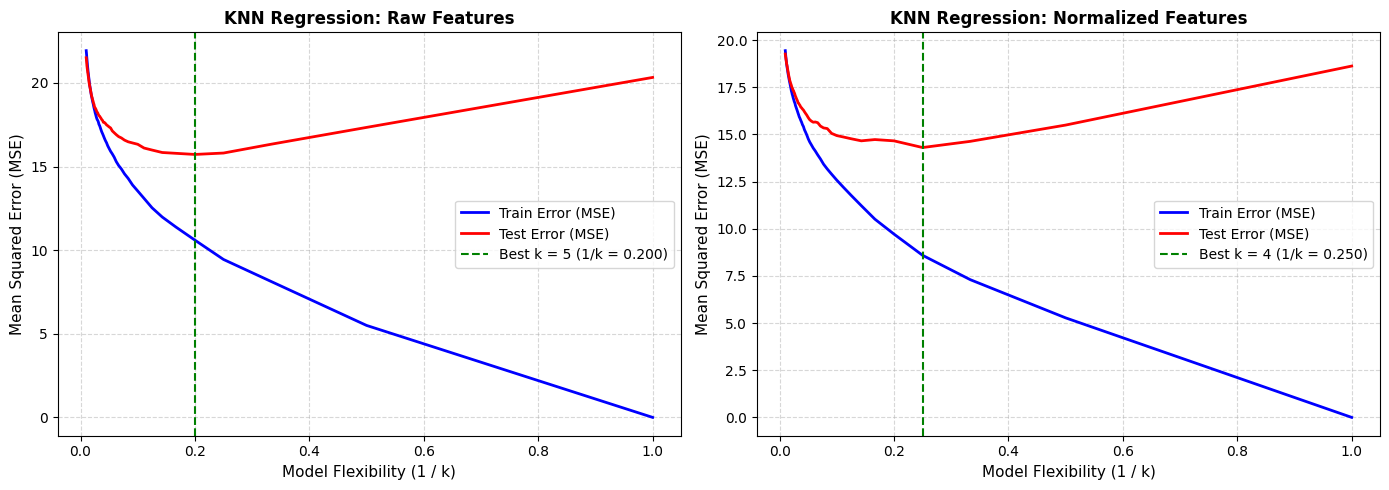

In [14]:
#1.(i)
### Plot the train and test errors in terms of 1/k. ### 

# Calculate 1/k values (Flexibility)
inv_k = 1 / k_range

# Create side-by-side plots for Raw and Scaled (Normalized) Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# - Plot 1: Raw Features -
axes[0].plot(inv_k, raw_tr_mse, label='Train Error (MSE)', color='blue', linewidth=2)
axes[0].plot(inv_k, raw_te_mse, label='Test Error (MSE)', color='red', linewidth=2)
axes[0].axvline(1 / best_k_raw, color='green', linestyle='--', label=f'Best k = {best_k_raw} (1/k = {1/best_k_raw:.3f})')
axes[0].set_title('KNN Regression: Raw Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model Flexibility (1 / k)', fontsize=11)
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# - Plot 2: Normalized Features -
axes[1].plot(inv_k, scl_tr_mse, label='Train Error (MSE)', color='blue', linewidth=2)
axes[1].plot(inv_k, scl_te_mse, label='Test Error (MSE)', color='red', linewidth=2)
axes[1].axvline(1 / best_k_scl, color='green', linestyle='--', label=f'Best k = {best_k_scl} (1/k = {1/best_k_scl:.3f})')
axes[1].set_title('KNN Regression: Normalized Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model Flexibility (1 / k)', fontsize=11)
axes[1].set_ylabel('Mean Squared Error (MSE)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

In [15]:
#1(j)
#### Summary Table of Model Performance ###
best_raw_knn_mse = raw_te_mse.min()
best_scl_knn_mse = scl_te_mse.min()

summary_table = pd.DataFrame([
    {
        'Category': 'Linear Models',
        'Model Name': 'Main Effects Only (1d)',
        'Best Hyperparameter': 'N/A',
        'Test MSE': m1_test_mse
    },
    {
        'Category': 'Linear Models',
        'Model Name': 'Interactions + Quadratics (1h)',
        'Best Hyperparameter': 'p < 0.05 terms',
        'Test MSE': m2_test_mse
    },
    {
        'Category': 'KNN',
        'Model Name': 'KNN (Raw Features)',
        'Best Hyperparameter': f'k = {best_k_raw}',
        'Test MSE': best_raw_knn_mse
    },
    {
        'Category': 'KNN',
        'Model Name': 'KNN (Normalized Features)',
        'Best Hyperparameter': f'k = {best_k_scl}',
        'Test MSE': best_scl_knn_mse
    }
])

# Identify lowest Test MSE programmatically
best_model_row = summary_table.loc[summary_table['Test MSE'].idxmin()]

print("--- SUMMARY TABLE ---")
print(summary_table.to_string(index=False))
print("\n--- TOP PERFORMING MODEL ---")
print(f"Model: {best_model_row['Model Name']} ({best_model_row['Best Hyperparameter']})")
print(f"Lowest Test MSE: {best_model_row['Test MSE']:.4f}")

--- SUMMARY TABLE ---
     Category                     Model Name Best Hyperparameter  Test MSE
Linear Models         Main Effects Only (1d)                 N/A 21.239857
Linear Models Interactions + Quadratics (1h)      p < 0.05 terms 18.650348
          KNN             KNN (Raw Features)               k = 5 15.726820
          KNN      KNN (Normalized Features)               k = 4 14.305669

--- TOP PERFORMING MODEL ---
Model: KNN (Normalized Features) (k = 4)
Lowest Test MSE: 14.3057


KNN v. Linear Regression Analysis



## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

An extremely large sample size n and a small number of predictors p would lead to a BETTER performance. The flexible method prevents overfitting, while 
demonstraing complex patterns. 

Text readings (ISLR) support this claim, "flexible methods, the variance will increase and the bias will decrease. The relative rate of change of these two quantities determines whether the test MSE increases or decreases. As we increase the flexibility of a class of methods, the bias tends to initially decrease faster than the variance increases."

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible statistical learning method with an extremely large number of predictors p, and small nunber of n would result in WORSE perfomance than an inflexible method. This is due to the immensive number of predictors (p) compared to observations (n) lead to overfitting and an increase in test errors. An inflexible method would support the variance. 

### (c) The relationship between the predictors and response is highly non-linear.

The results from predictors and responses being non-linear is BETTER with flexible methods. It will adapt to the non-linear curves and limit bias, while inflexible methods are more rigid resulting in high levels of bias. 

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

In the case the variance of error terms is extremely high, flexible methods are WORSE than inflexible methods. Flexible methods would adhere to overfitting due to a lot of random noise. 

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

obs. 1 d = 3.00
obs. 2 d = 2.00
obs. 3 d = 3.16
obs. 4 d = 2.24
obs. 5 d = 1.41
obs. 6 d = 1.73

### (b) What is our prediction with K = 1? Why?

Prediction : Green
obs. 5 d = 1.41

### (c) What is our prediction with K = 3? Why?

Prediction : Red
obs. 5 d= 1.41, Y = Green
obs. 6 d = 1.73, Y = Red
obs. 2 d = 2.00, Y = Red

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Prediction : Small
Justification : A small value for K results in low bias. A high value for K leads to less flexibility and high bias. 